In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / "results"
DATA_DIR = ROOT_DIR / "data"
PROTEIN_DATA_DIR = DATA_DIR / "protein" / "aggregated_all"
EMBRYO_TRACKS_PATH = DATA_DIR / "embryo1" / "tracks.txt"
EMBRYONIC_TERMINALS_PATH = DATA_DIR / "embryonic_terminals.txt"
GENE_DATA_PATH = DATA_DIR / "gene_data.txt"
TISSUE_SPECIFIC_TF_PATH = PROTEIN_DATA_DIR / "tissue_specific_tf.tsv"
AR_FEATURE_IMPORTANCE_PATH = RESULTS_DIR / "ar_feature_importance.tsv"
AR_EMBEDDINGS_PATH = RESULTS_DIR / "ar_embeddings_32d.csv"
NN_EMBEDDINGS_PATH = RESULTS_DIR / "embeddings_32d.csv"
NN_SELECTED_PATH = RESULTS_DIR / "nn_selected_proteins_rev.tsv"
S3_ZSCORE_PATH = PROTEIN_DATA_DIR / "s3_zscore.csv"
LINEAGE_BINARY_EXPRESSION_PATH = PROTEIN_DATA_DIR / "lineage_binary_expression.csv"
S3_PCA_10D_PATH = PROTEIN_DATA_DIR / "s3_pca_10d.csv"
VISCELLO_EXPR_PATH = DATA_DIR / "viscello" / "lin_sc_expr_190602.rds"
CELL_TYPE_PATH = DATA_DIR / "2023-06-29_entropy_cell_key_V2.csv"
CELL_LINEAGE_PATH = DATA_DIR / "cell_lineage.json"

t_threshold = 255
ts_df = pd.read_csv(EMBRYO_TRACKS_PATH, sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv(EMBRYONIC_TERMINALS_PATH, sep='\t', header=None)[0].tolist()
tissue_specific_tfs = pd.read_csv(TISSUE_SPECIFIC_TF_PATH, sep='\t', header=None, index_col=0).index.tolist()
ar_selected_tfs = pd.read_csv(AR_FEATURE_IMPORTANCE_PATH, sep='\t', header=None, index_col=0).index.tolist()


In [42]:
nn_selected_tfs = ar_selected_tfs[:15]
nn_selected_tfs = pd.read_csv(NN_SELECTED_PATH, sep='\t', header=None, index_col=0).index.tolist()

In [5]:
gene_data_df = pd.read_csv(GENE_DATA_PATH, sep='\t', index_col=0)
gene_data_df.index = gene_data_df.index.str.upper()
gene_data_df.head()

,jsd_median_term,jsd_lower_term,jsd_upper_term,pcor_median_term,pcor_lower_term,pcor_upper_term,scor_median_term,scor_lower_term,scor_upper_term,cos_median_term,...,operon,maternal,RecombRegion,RNAi_or_Allele,embryonic_lethal_direct,embryonic_lethal_direct_inferred,larval_lethal_direct,larval_lethal_direct_inferred,lethal_direct,lethal_direct_inferred
gene,,,,,,,,,,,,,,,,,,,,,
2L52.1,0.450554,0.428416,0.469560,0.289454,0.213473,0.364712,0.352485,0.296098,0.413772,0.365775,...,N.A.,False,II_LeftTip,False,False,False,False,False,False,False
RGA-9,0.350676,0.336391,0.365963,0.603602,0.541112,0.655173,0.627157,0.584258,0.665822,0.235889,...,N.A.,False,II_RightTip,False,False,False,False,False,False,False
NAS-6,0.551291,0.524371,0.576493,0.403508,0.347128,0.455199,0.286374,0.216116,0.356301,0.184228,...,N.A.,False,IV_RightTip,True,False,False,False,False,True,True
RABR-2,0.662402,0.603275,0.711242,0.374094,0.301252,0.449785,0.252592,0.176470,0.325485,0.384001,...,N.A.,False,IV_RightTip,True,False,False,False,False,False,False
SRI-20,0.922031,0.831150,0.980238,0.069098,-0.056399,0.206172,0.144529,0.053946,0.229579,0.886603,...,N.A.,False,V_Center,False,False,False,False,False,False,False


In [6]:
candidate_tfs = set(tissue_specific_tfs) & set(nn_selected_tfs)
candidate_tfs = nn_selected_tfs
print(f"Number of candidate tissue-specific TFs: {len(candidate_tfs)}")

Number of candidate tissue-specific TFs: 15


In [7]:
# get the gene_data_df for all tissue specific TFs that are in the gene_data_df
tissue_specific_tfs_in_gene_data = [tf for tf in candidate_tfs if tf in gene_data_df.index]
tissue_specific_tf_data_df = gene_data_df.loc[tissue_specific_tfs_in_gene_data]
tissue_specific_tf_data_df['cel_tau_median_joint'].sort_values(ascending=False).head(15)


gene
TAB-1      0.767036
HLH-1      0.694460
SPTF-1     0.654645
CEH-43     0.563979
ALY-2      0.518769
EGL-18     0.482525
EFL-1      0.454567
HBL-1      0.417869
LIN-15B    0.417498
HMG-4      0.343285
ZTF-6      0.292757
ALY-1      0.284091
CEH-38     0.275713
LSY-2      0.263272
MEP-1      0.230146
Name: cel_tau_median_joint, dtype: float64

In [44]:
include_embryonic_terminals = False


In [45]:
lineage_exp = pd.read_csv(NN_EMBEDDINGS_PATH, index_col=0).T
protein_exp = pd.read_csv(S3_ZSCORE_PATH, index_col=0)
binary_protein_exp = pd.read_csv(LINEAGE_BINARY_EXPRESSION_PATH, index_col=0)
protein_exp = protein_exp.fillna(0)
protein_exp = protein_exp.loc[protein_exp.sum(axis=1) != 0, :]
lineage_exp = lineage_exp.fillna(0)

In [46]:
protein_pca_exp = pd.read_csv(S3_PCA_10D_PATH, index_col=0).T
protein_pca_exp = protein_pca_exp.fillna(0)

In [47]:
protein_tau_values = []
for index_name, row in protein_exp.iterrows():
    protein_name = index_name.split("_")[0]
    if protein_name in tissue_specific_tf_data_df.index:
        tau = (1 - row / row.max()).sum()/(len(row) - 1)
        protein_tau_values.append(tau)


In [48]:
tf_names = set()
for name in protein_exp.index:
    tf_name = name.split('_')[0]
    if '.' in tf_name:
        tf_names.add(tf_name)
    else:
        tf_names.add(tf_name.lower())


In [49]:
selected_rows = []
for protein_name in protein_exp.index:
    tf_name = protein_name.split("_")[0]
    if tf_name in candidate_tfs:
        selected_rows.append(protein_name)
protein_exp = protein_exp.loc[selected_rows, :]
binary_protein_exp = binary_protein_exp.loc[selected_rows, :]

In [50]:
alt_exp = read_r(str(VISCELLO_EXPR_PATH))[None]
alt_tf_exp = alt_exp.loc[alt_exp.index.isin(tf_names)]

# randomly pick 20 genes as random baseline
random_genes = np.random.choice(alt_exp.index, size=20, replace=False)
random_exp = alt_exp.loc[random_genes]

# do a 10d pca on the alt_tf_exp
pca = PCA(n_components=10)
alt_tf_exp_pca = pca.fit_transform(alt_tf_exp.T)
alt_tf_exp_pca_df = pd.DataFrame(alt_tf_exp_pca, index=alt_tf_exp.columns, columns=[f"PC{i+1}" for i in range(10)])
alt_tf_exp_pca_df = alt_tf_exp_pca_df.T

In [51]:
selected_rows = []
for protein_name in alt_tf_exp.index:
    tf_name = protein_name.split("_")[0].upper()
    if tf_name in candidate_tfs:
        selected_rows.append(protein_name)
alt_tf_exp = alt_tf_exp.loc[selected_rows, :]

In [52]:
len(valid_cell_names)

1006

In [53]:
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns)).intersection(set(alt_exp.columns))
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns))

# pca = PCA(n_components=20)
# alt_exp_pca = pca.fit_transform(alt_exp.T)
# alt_exp_pca_df = pd.DataFrame(alt_exp_pca, index=alt_exp.columns,
#                                columns=[f'PC{i+1}' for i in range(20)]).T


In [54]:
cell_type_df = pd.read_csv(CELL_TYPE_PATH)
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [55]:
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)

In [56]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
node_ancestry = defaultdict(list)
terminal_name_to_idx = {}

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    node_ancestry[lookup_name] = ancestors
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)


In [57]:
def lineage_distance(cell1, cell2):
    ancestors1 = node_ancestry[cell1]
    ancestors2 = node_ancestry[cell2]
    common_ancestors = set(ancestors1).intersection(set(ancestors2))
    if not common_ancestors:
        return len(ancestors1) + len(ancestors2)
    last_common_ancestor = max(common_ancestors, key=lambda x: ancestors1.index(x))
    distance = (len(ancestors1) - ancestors1.index(last_common_ancestor) - 1) + (len(ancestors2) - ancestors2.index(last_common_ancestor) - 1)
    return distance

In [58]:
alt_tf_exp_dict = {}
for colname in alt_tf_exp.columns:
    alt_tf_exp_dict[colname] = alt_tf_exp[colname].values

In [59]:
lineage_distances = []
exp_distances = []
for i in tqdm(range(len(lineage_exp.columns))):
    for j in range(i + 1, len(lineage_exp.columns)):
        cell1 = lineage_exp.columns[i]
        cell2 = lineage_exp.columns[j]
        dist = lineage_distance(cell1, cell2)
        if cell1 not in lineage_exp or cell2 not in lineage_exp:
            continue
        exp_distance = np.linalg.norm(lineage_exp[cell1] - lineage_exp[cell2])
        exp_distances.append(exp_distance)
        lineage_distances.append(dist)
        # print(f"Lineage distance between {cell1} and {cell2}: {dist}")

100%|██████████| 1204/1204 [00:16<00:00, 72.92it/s] 


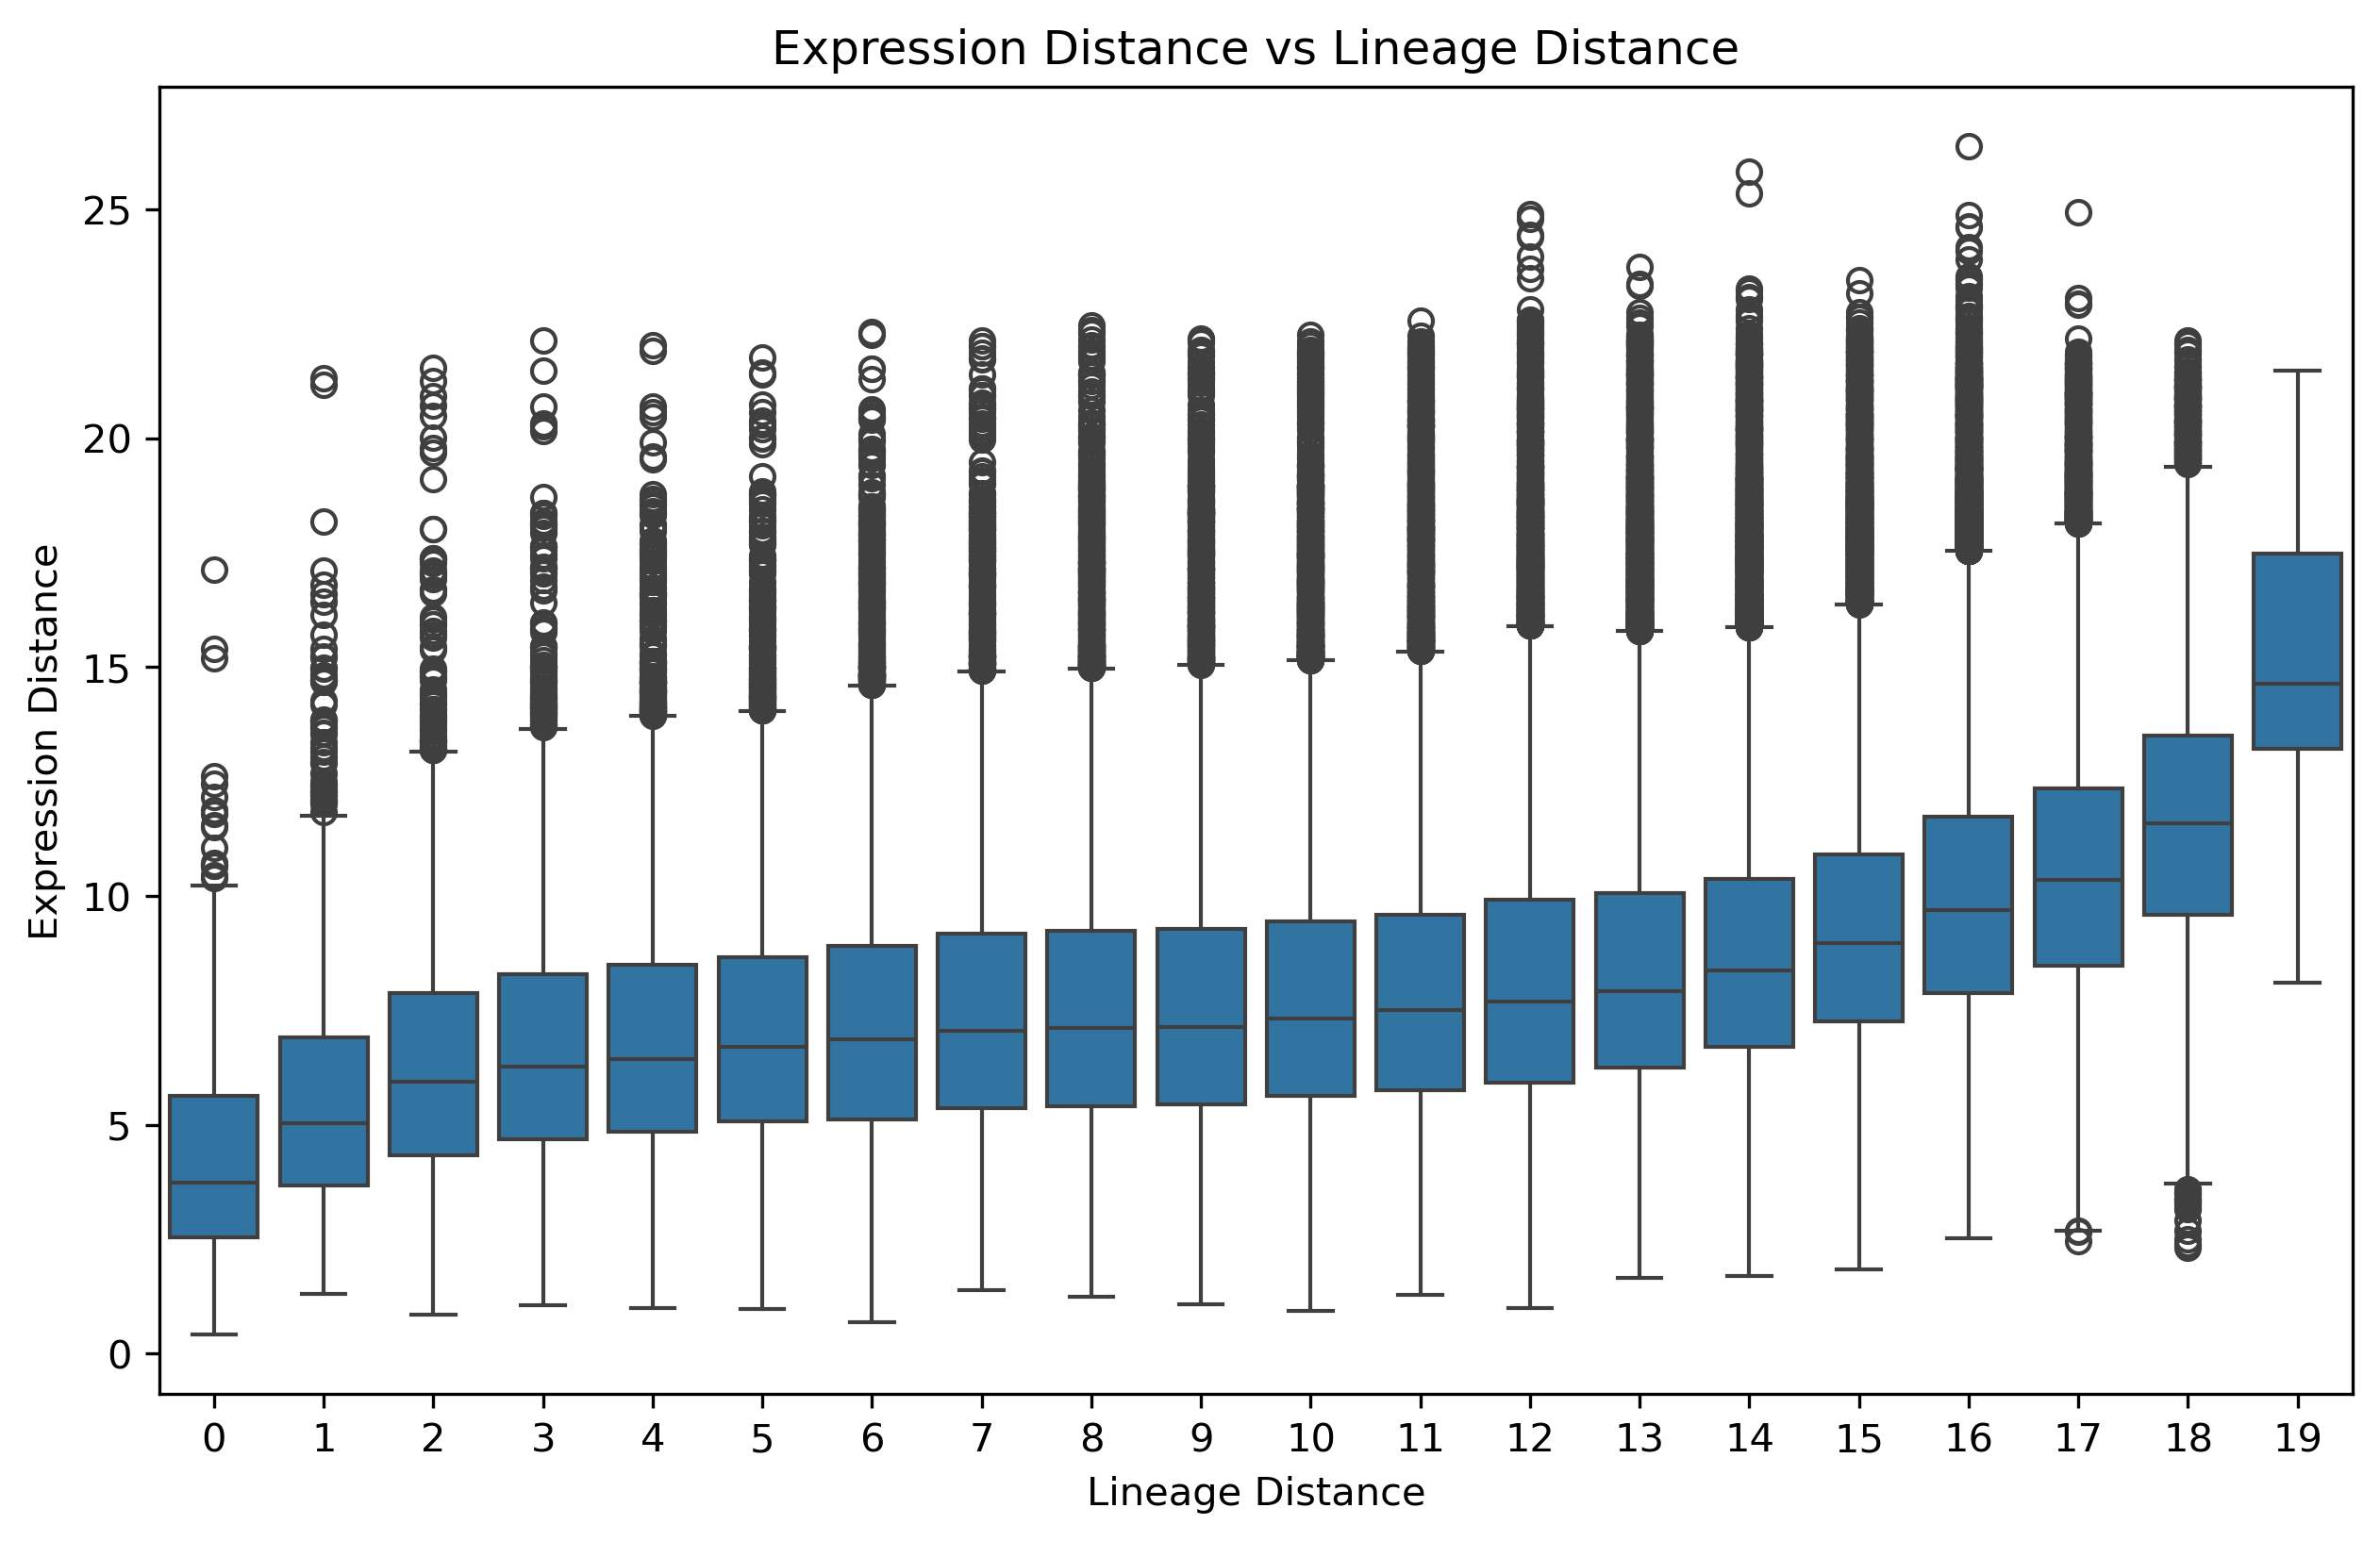

In [60]:
# plot lineage_distances againgst jsd_distances
# since lineage distance is discrete and jsd_distance is continuous we create a boxplot for each lineage distance
lineage_jsd_df = pd.DataFrame({'lineage_distance': lineage_distances, 'exp_distance': exp_distances})
plt.figure(figsize=(10, 6))
sns.boxplot(x='lineage_distance', y='exp_distance', data=lineage_jsd_df)
plt.title('Expression Distance vs Lineage Distance')
plt.xlabel('Lineage Distance')
plt.ylabel('Expression Distance')
plt.show()

In [61]:
same_type_siblings = []
diff_type_siblings = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        same_type_siblings.append(children)
    elif len(child_types) > 1:
        diff_type_siblings.append(children)


In [62]:
same_type_dist_mean = []
same_type_dist_std = []
diff_type_dist_mean = []
diff_type_dist_std = []
for tf in protein_exp.index:
    tf_values = protein_exp.loc[tf]
    distances = []
    for sib1, sib2 in same_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    same_type_dist_mean.append(np.mean(distances))
    same_type_dist_std.append(np.std(distances))
    distances = []
    for sib1, sib2 in diff_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    diff_type_dist_mean.append(np.mean(distances))
    diff_type_dist_std.append(np.std(distances))

dist_df = pd.DataFrame({
    "TF": protein_exp.index,
    "Same Type Siblings Mean Distance": same_type_dist_mean,
    "Same Type Siblings Std Distance": same_type_dist_std,
    "Diff Type Siblings Mean Distance": diff_type_dist_mean,
    "Diff Type Siblings Std Distance": diff_type_dist_std,
})
dist_df.index = dist_df["TF"]


In [63]:
xyz_coord_dict = {}
exp_vector_dict = {}
alt_exp_vector_dict = {}
embedded_exp_vector_dict = {}

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = protein_exp.loc[:, node].values
    exp_vector_dict[parent] = protein_exp.loc[:, parent].values
    alt_exp_vector_dict[node] = alt_tf_exp.loc[:, node].values
    alt_exp_vector_dict[parent] = alt_tf_exp.loc[:, parent].values
    embedded_exp_vector_dict[node] = lineage_exp.loc[:, node].values
    embedded_exp_vector_dict[parent] = lineage_exp.loc[:, parent].values


In [64]:
siblings_exp_distances_with_same_type = []
siblings_exp_distances_with_diff_type = []
sibling_parent_distances_with_same_type = []
sibling_parent_distances_with_diff_type = []

for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        siblings_exp_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))
    elif len(child_types) > 1:
        siblings_exp_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))

    # if len(child_types) == 1 and len(children) > 1:
    #     siblings_exp_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))
    # elif len(child_types) > 1:
    #     siblings_exp_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))


In [65]:
print(f"Avg sibling expression distance with same type: {np.mean(siblings_exp_distances_with_same_type):.4f}")
print(f"Avg sibling expression distance with different type: {np.mean(siblings_exp_distances_with_diff_type):.4f}")
print(f"Avg sibling-parent expression distance with same type: {np.mean(sibling_parent_distances_with_same_type):.4f}")
print(f"Avg sibling-parent expression distance with different type: {np.mean(sibling_parent_distances_with_diff_type):.4f}")


Avg sibling expression distance with same type: 4.5306
Avg sibling expression distance with different type: 5.6548
Avg sibling-parent expression distance with same type: 6.4848
Avg sibling-parent expression distance with different type: 6.4056


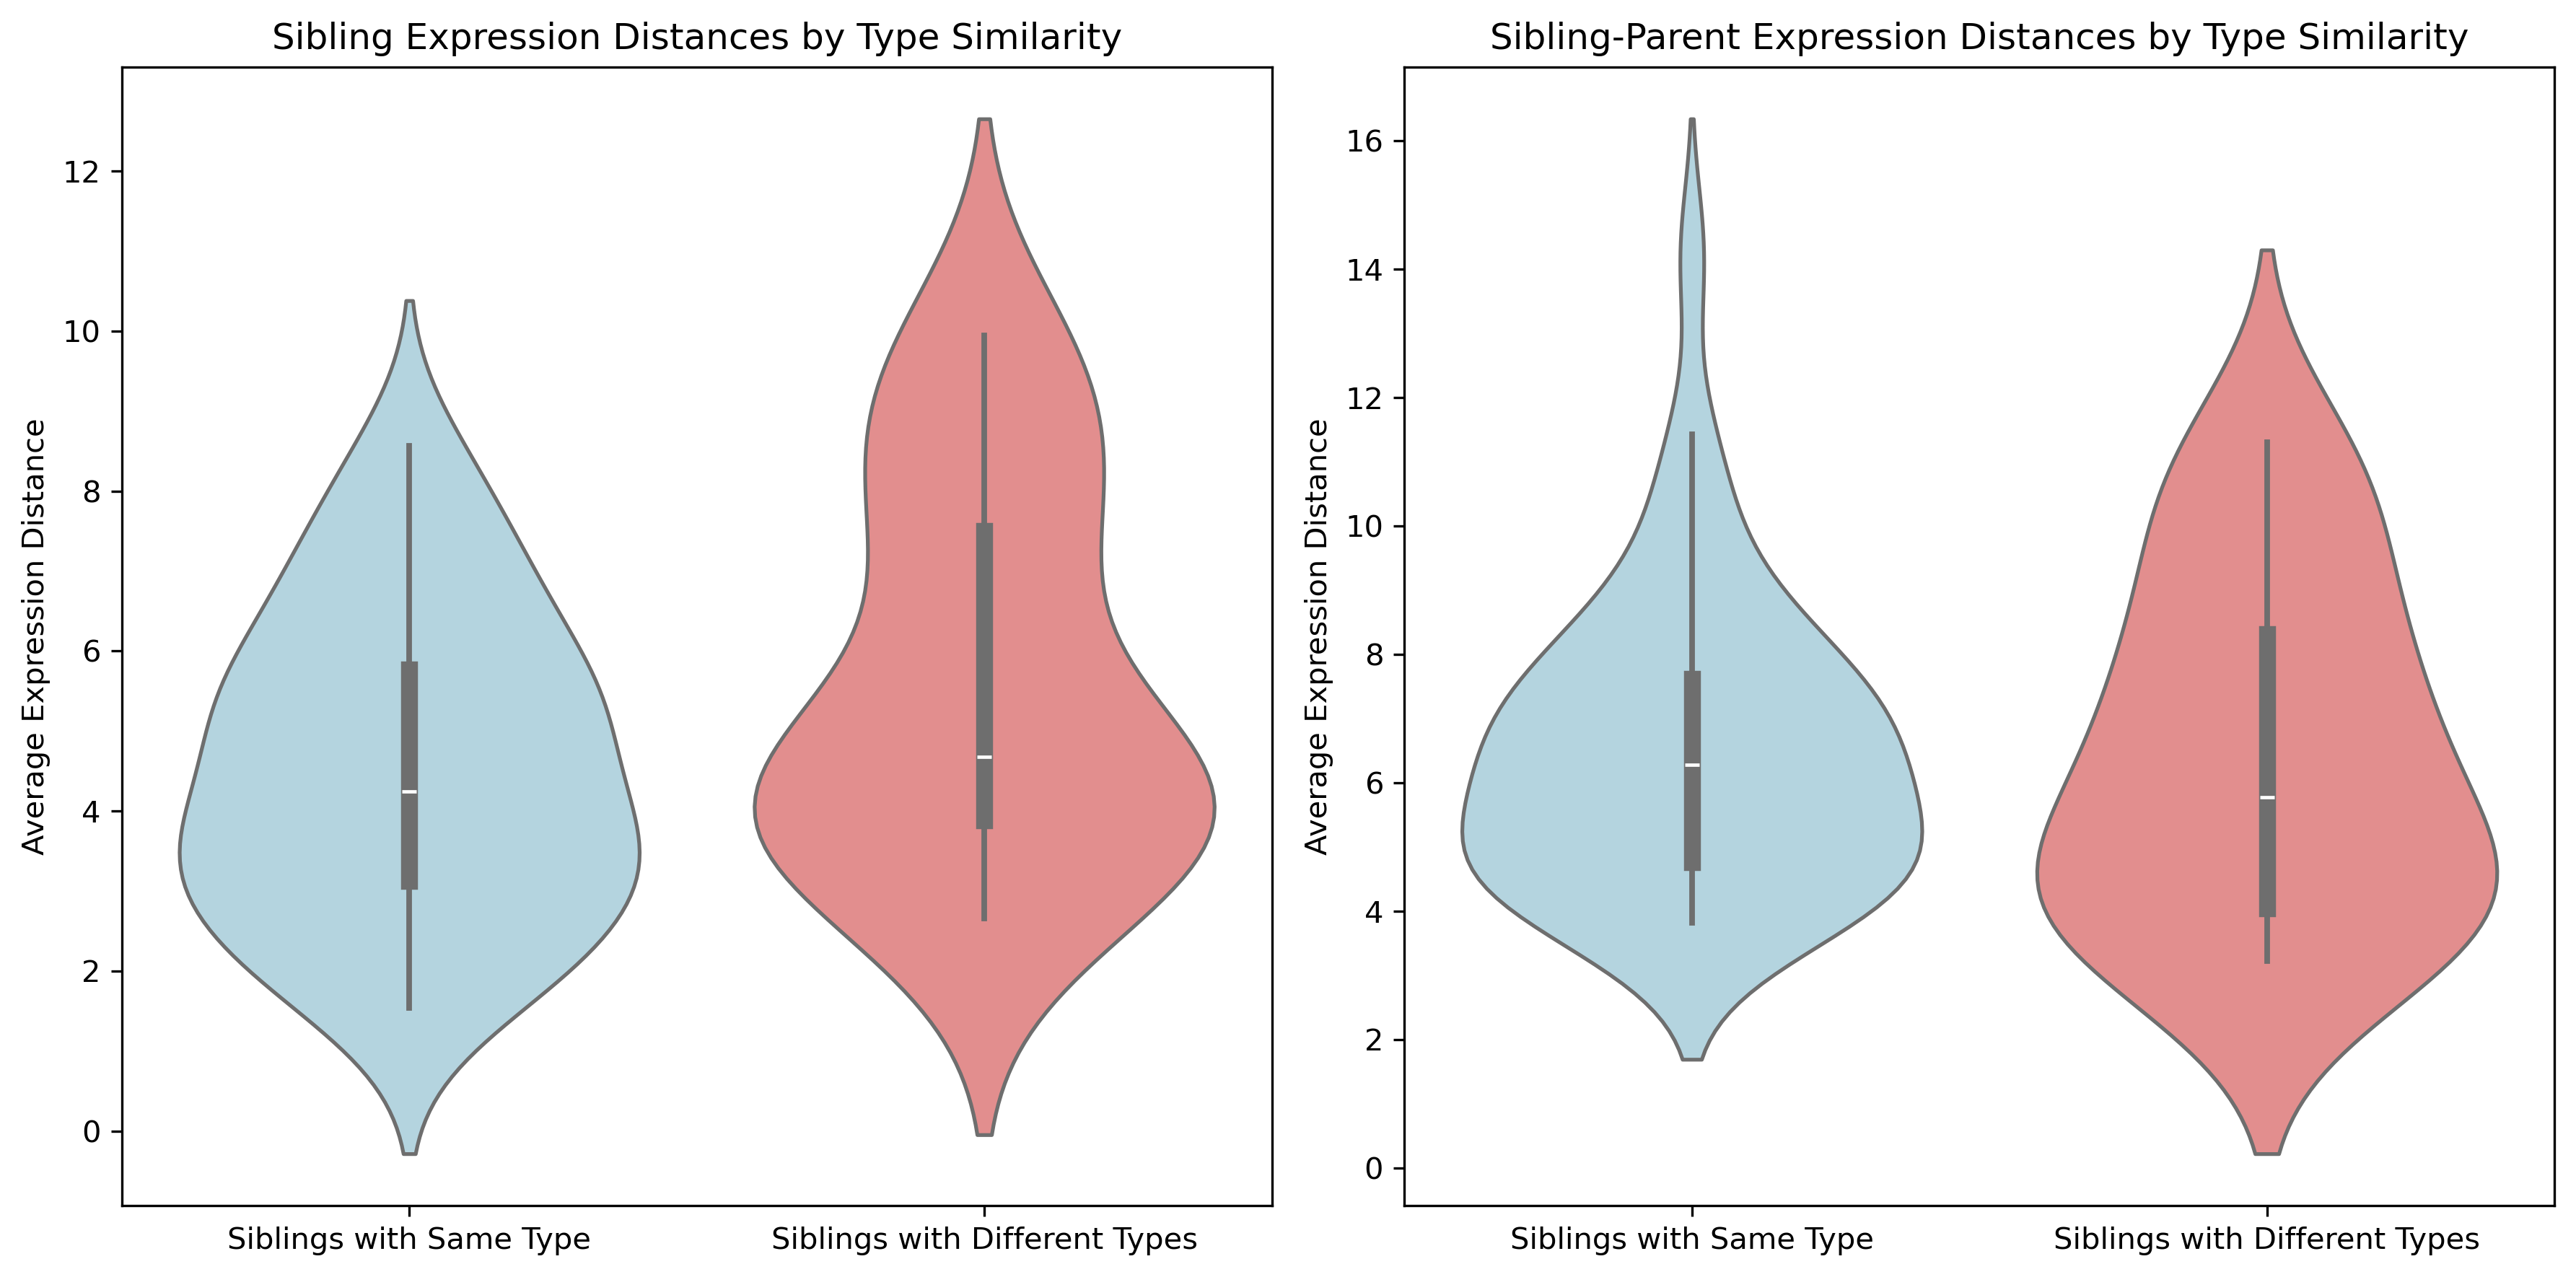

In [66]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=[siblings_exp_distances_with_same_type, siblings_exp_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling Expression Distances by Type Similarity')

plt.subplot(1, 2, 2)
sns.violinplot(data=[sibling_parent_distances_with_same_type, sibling_parent_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling-Parent Expression Distances by Type Similarity')
plt.tight_layout()
plt.show()


In [67]:
xyz_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
alt_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
embedded_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))

for i, parent in enumerate(terminal_parents):
    for j, node in enumerate(terminal_nodes):
        xyz_cost_mat[i, j] = np.linalg.norm(xyz_coord_dict[parent] - xyz_coord_dict[node])
        exp_cost_mat[i, j] = np.linalg.norm(exp_vector_dict[parent] - exp_vector_dict[node])
        alt_exp_cost_mat[i, j] = np.linalg.norm(alt_tf_exp_pca_df[parent] - alt_tf_exp_pca_df[node])
        embedded_exp_cost_mat[i, j] = np.linalg.norm(embedded_exp_vector_dict[parent] - embedded_exp_vector_dict[node])

lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
lineage_exp_cost = exp_cost_mat.diagonal().sum()
lineage_alt_exp_cost = alt_exp_cost_mat.diagonal().sum()
lineage_embedded_exp_cost = embedded_exp_cost_mat.diagonal().sum()


Pearson correlation


,protein_tf_cost,scrna_cost,embedding_cost
protein_tf_cost,1.000000,0.074020,0.300142
scrna_cost,0.074020,1.000000,0.158082
embedding_cost,0.300142,0.158082,1.000000


Spearman correlation


,protein_tf_cost,scrna_cost,embedding_cost
protein_tf_cost,1.000000,0.084296,0.356634
scrna_cost,0.084296,1.000000,0.134868
embedding_cost,0.356634,0.134868,1.000000


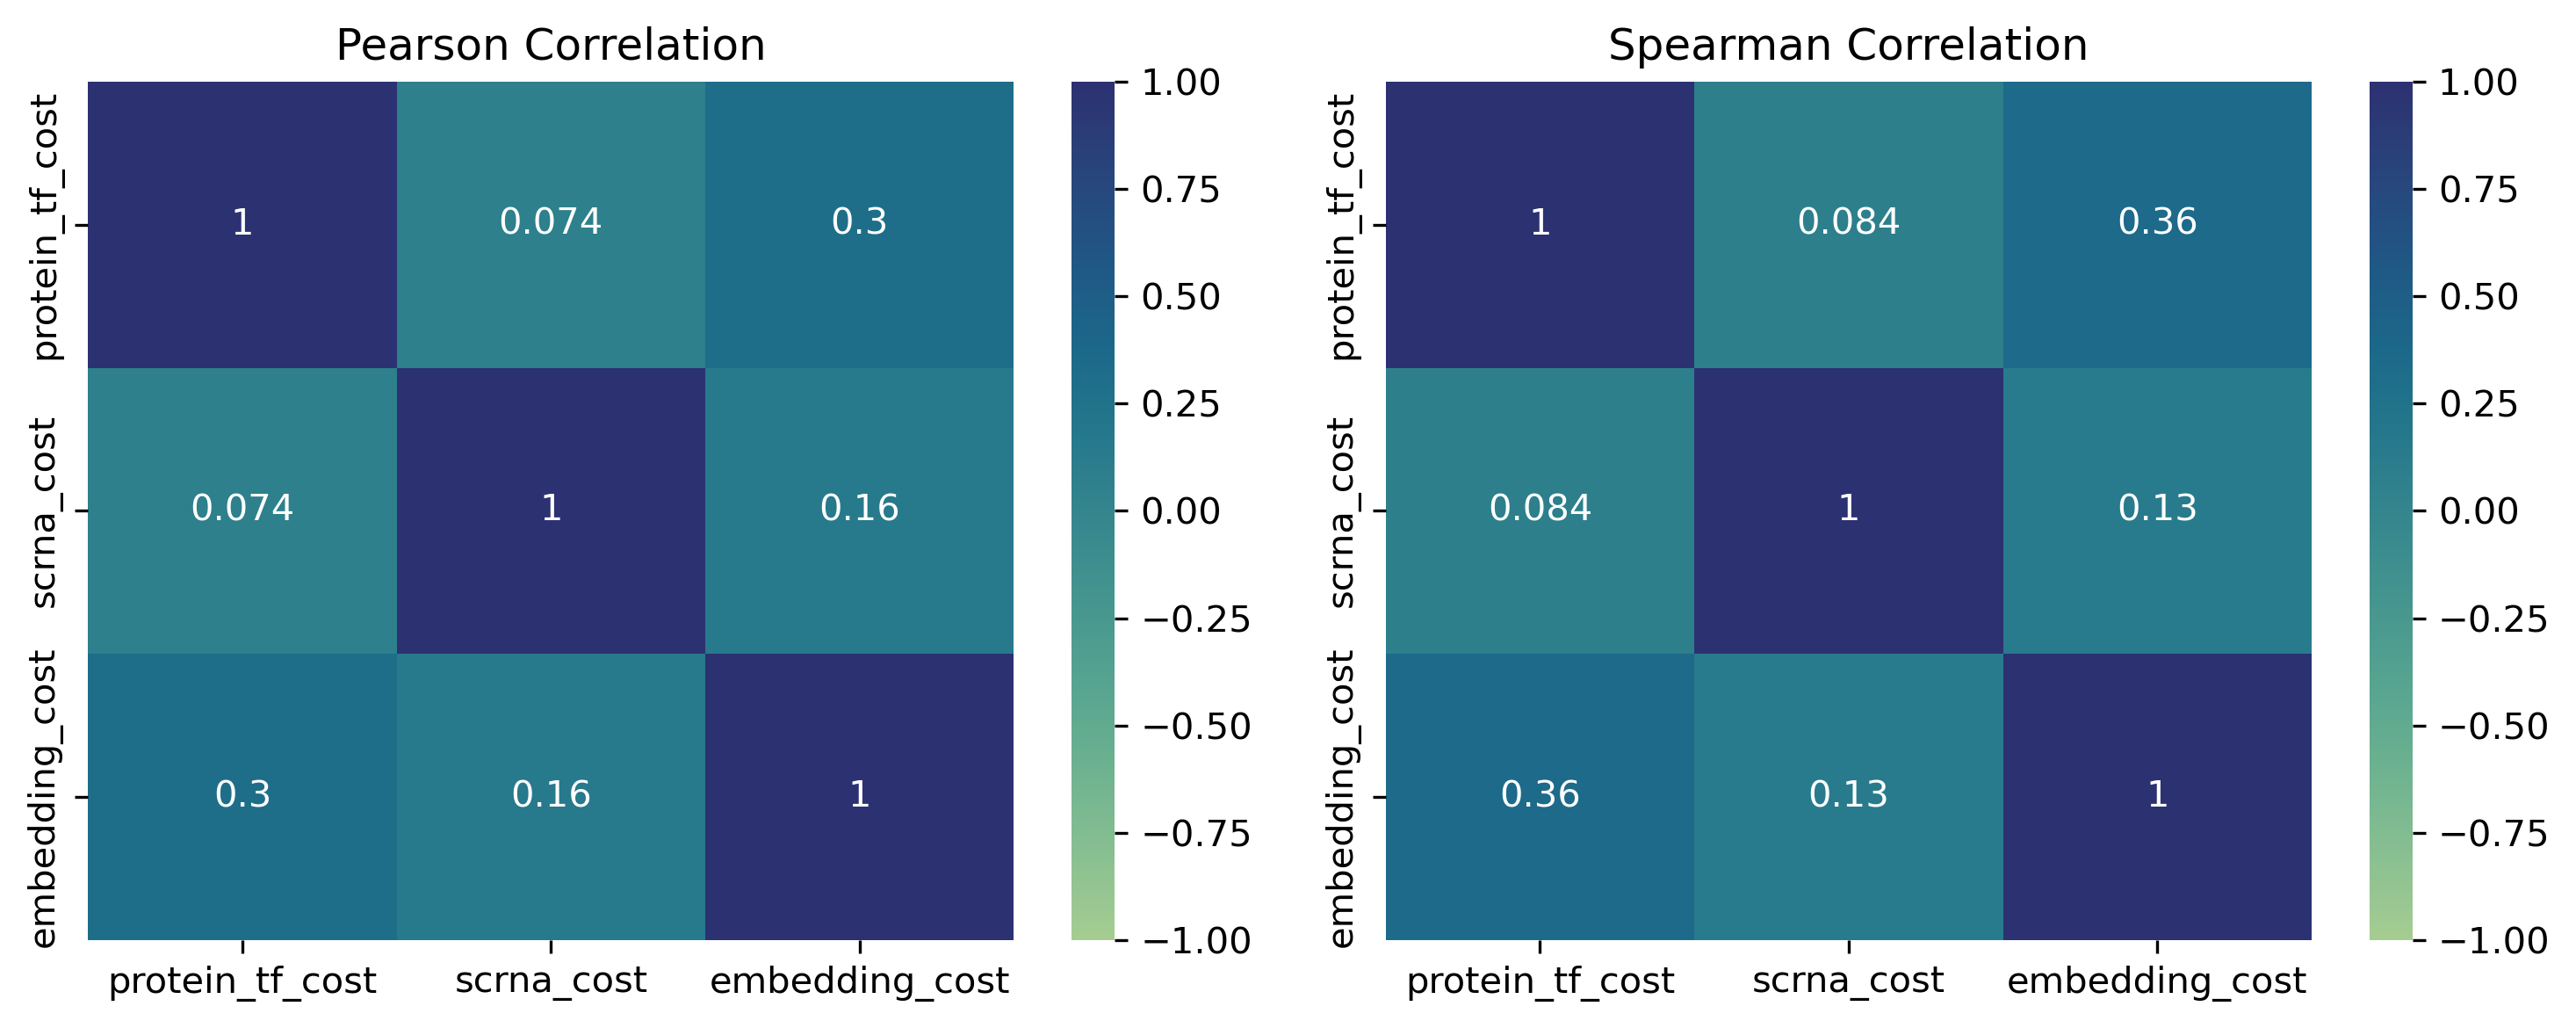

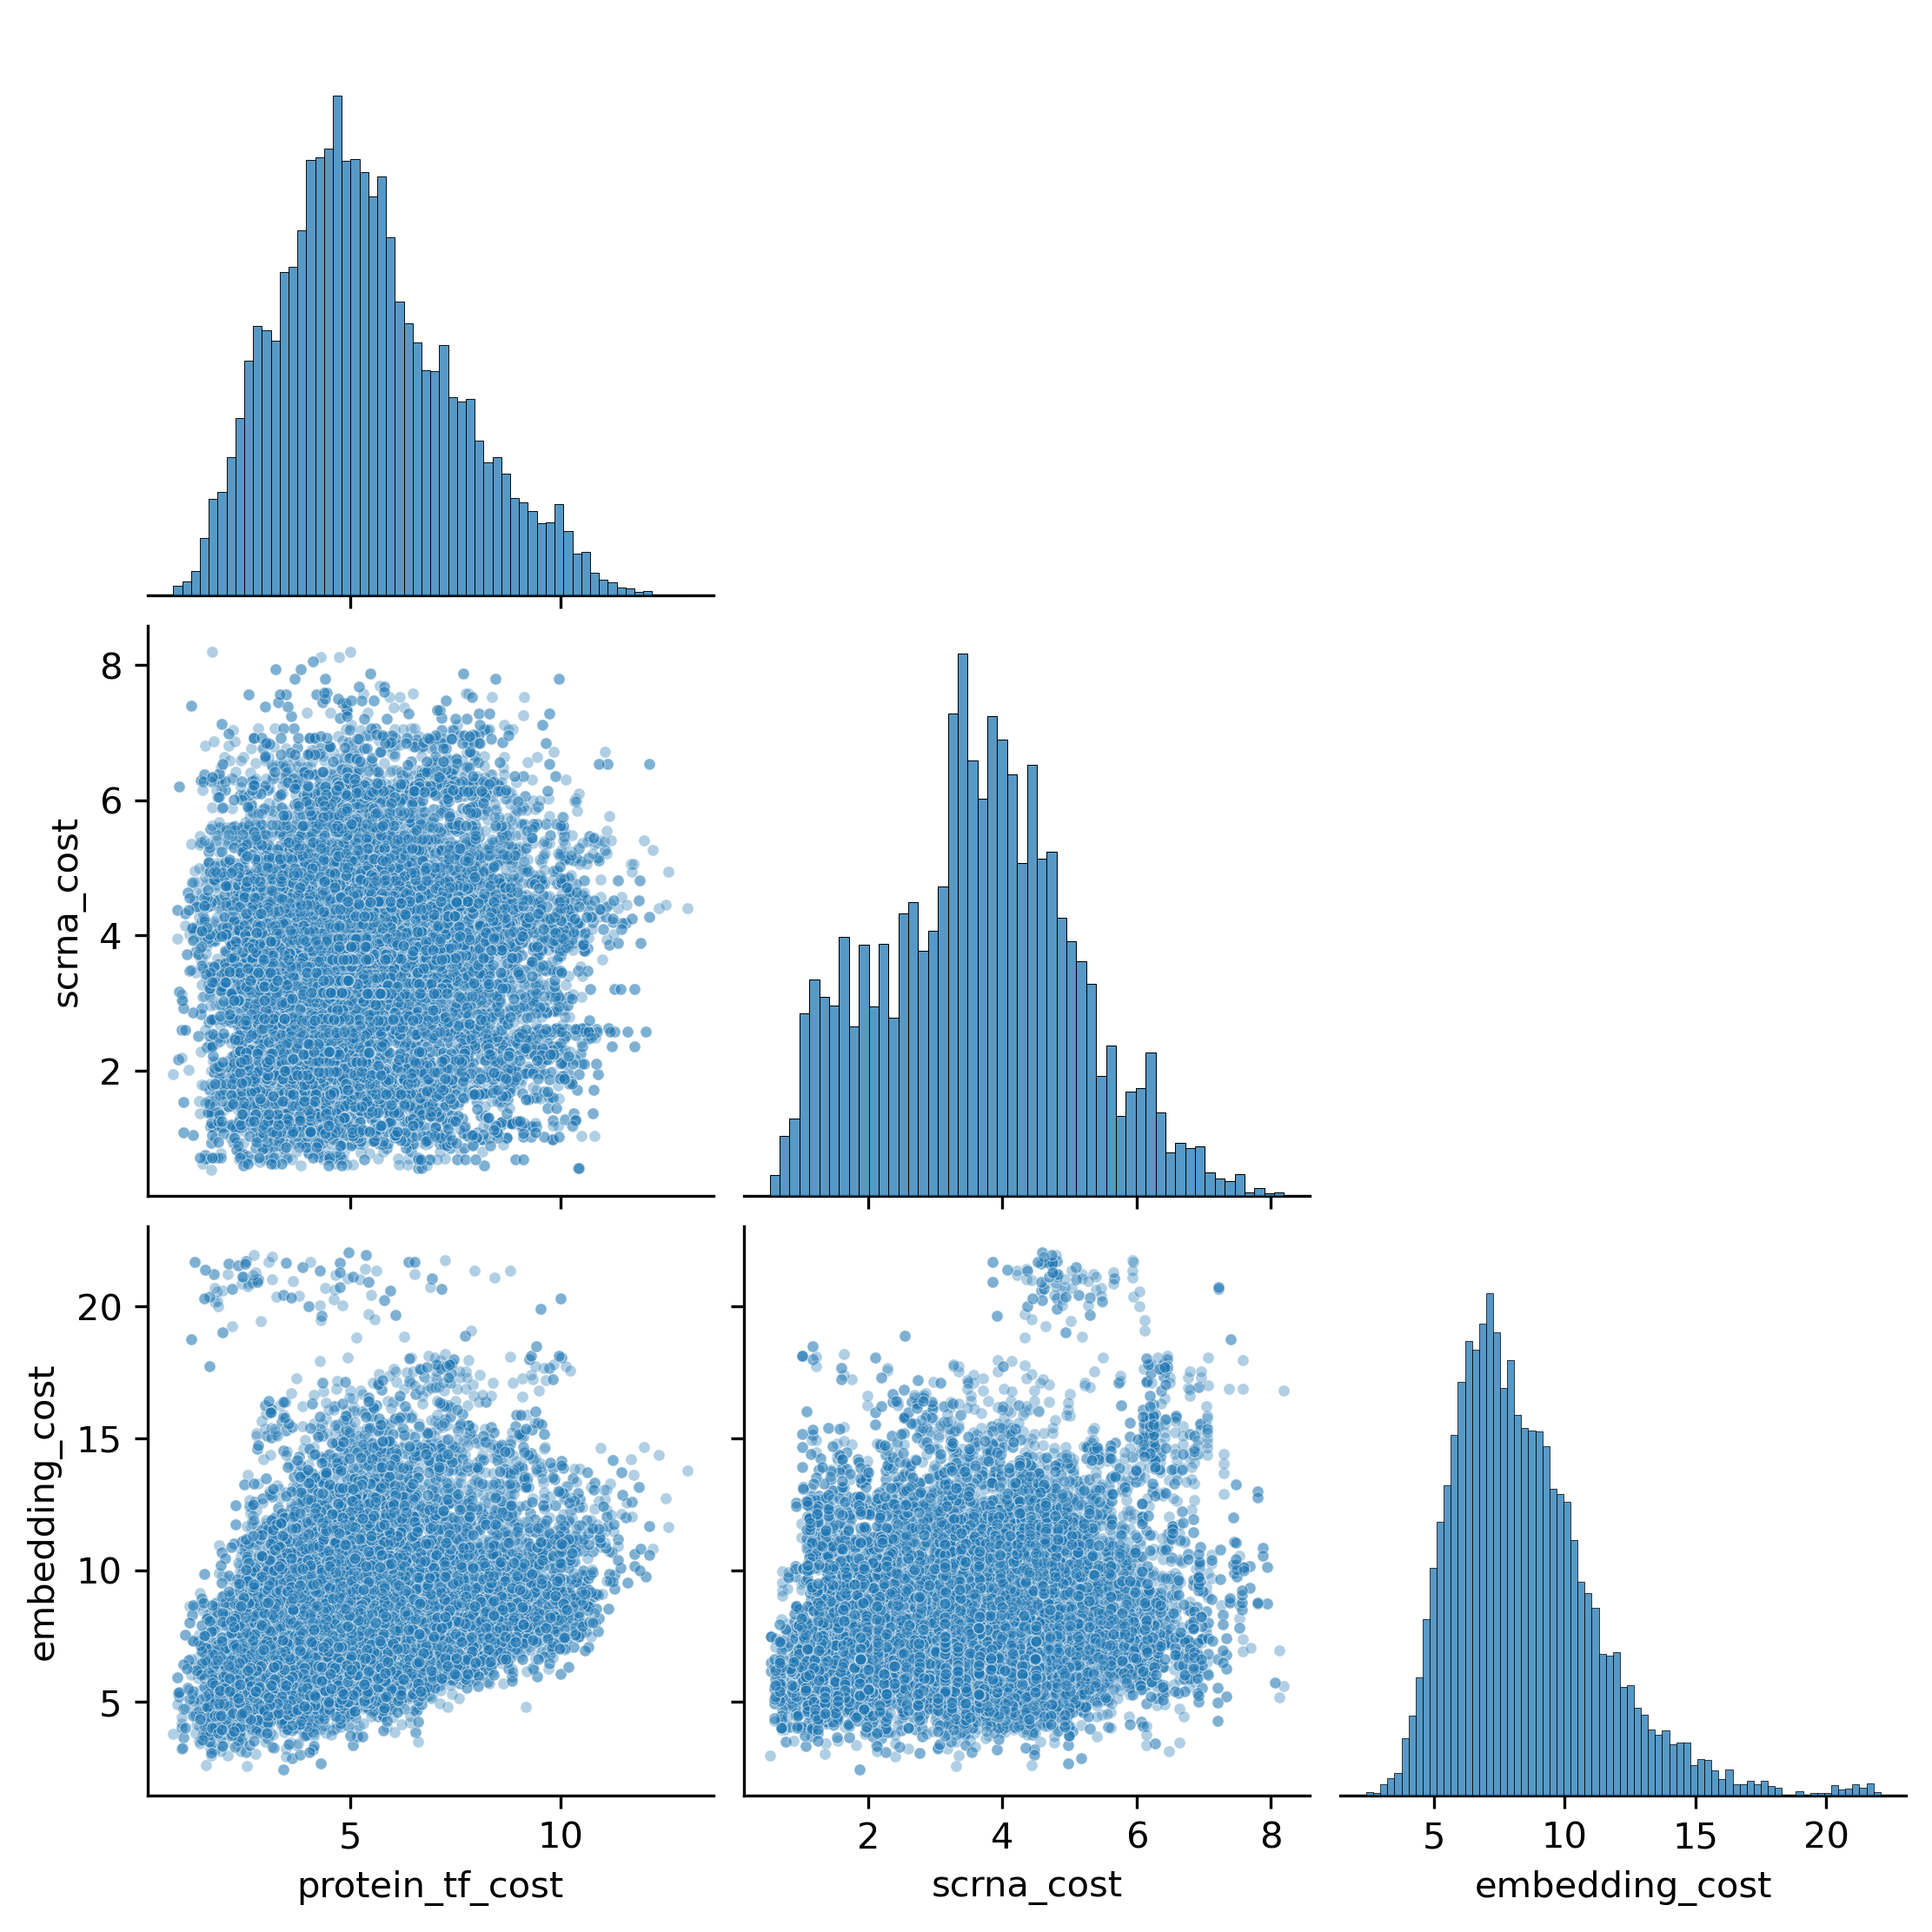

In [68]:
upper_triangle_mask = np.triu(np.ones(exp_cost_mat.shape, dtype=bool), k=1)

cost_comparison_df = pd.DataFrame({
    'protein_tf_cost': exp_cost_mat[upper_triangle_mask],
    'scrna_cost': alt_exp_cost_mat[upper_triangle_mask],
    'embedding_cost': embedded_exp_cost_mat[upper_triangle_mask],
})

pearson_corr = cost_comparison_df.corr(method='pearson')
spearman_corr = cost_comparison_df.corr(method='spearman')

print('Pearson correlation')
display(pearson_corr)
print('Spearman correlation')
display(spearman_corr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(pearson_corr, annot=True, cmap='crest', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')
sns.heatmap(spearman_corr, annot=True, cmap='crest', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')
plt.tight_layout()
plt.show()

sns.pairplot(cost_comparison_df, kind='scatter', corner=True, plot_kws={'s': 10, 'alpha': 0.35})
plt.show()

In [69]:
def pareto_exp_comp(chosen_exp_cost, title):
    pareto_xyz_costs = []
    pareto_exp_costs = []
    pareto_alt_exp_costs = []
    pareto_house_keeping_exp_costs = []
    for i in tqdm(range(1001)):
        alpha = i / 1000.0
        combined_cost_mat = alpha * chosen_exp_cost + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_costs.append(exp_cost_mat[row_ind, col_ind].sum())
        pareto_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())
        pareto_house_keeping_exp_costs.append(embedded_exp_cost_mat[row_ind, col_ind].sum())
    
    def lineage_kept_ratio(cost_mat):
        row_ind, col_ind = linear_sum_assignment(cost_mat)
        return np.sum(row_ind == col_ind) / len(row_ind)
    
    print(f"Lineage kept ratio for real lineage when optimizing for xyz: {lineage_kept_ratio(xyz_cost_mat):.4f}")
    print(f"Lineage kept ratio for real lineage when optimizing for exp: {lineage_kept_ratio(exp_cost_mat):.4f}")
    print(f"Lineage kept ratio for real lineage when optimizing for alt_exp: {lineage_kept_ratio(alt_exp_cost_mat):.4f}")
    print(f"Lineage kept ratio for real lineage when optimizing for embedded_exp: {lineage_kept_ratio(embedded_exp_cost_mat):.4f}")

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
    fig.suptitle(title)
    ax1.plot(pareto_xyz_costs, pareto_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax1.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax1.set_ylabel('Protein-TF Cost')
    ax1.set_xlabel('Motility Cost')
    ax2.plot(pareto_xyz_costs, pareto_alt_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax2.scatter(lineage_xyz_cost, lineage_alt_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax2.set_ylabel('ScRNA Cost')
    ax2.set_xlabel('Motility Cost')
    ax3.plot(pareto_xyz_costs, pareto_house_keeping_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax3.scatter(lineage_xyz_cost, lineage_embedded_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax3.set_ylabel('Protein-Embedding Cost')
    ax3.set_xlabel('Motility Cost')
    plt.tight_layout()
    plt.show()


100%|██████████| 1001/1001 [00:00<00:00, 1493.32it/s]

Lineage kept ratio for real lineage when optimizing for xyz: 0.4444
Lineage kept ratio for real lineage when optimizing for exp: 0.1905
Lineage kept ratio for real lineage when optimizing for alt_exp: 0.0582
Lineage kept ratio for real lineage when optimizing for embedded_exp: 0.1693


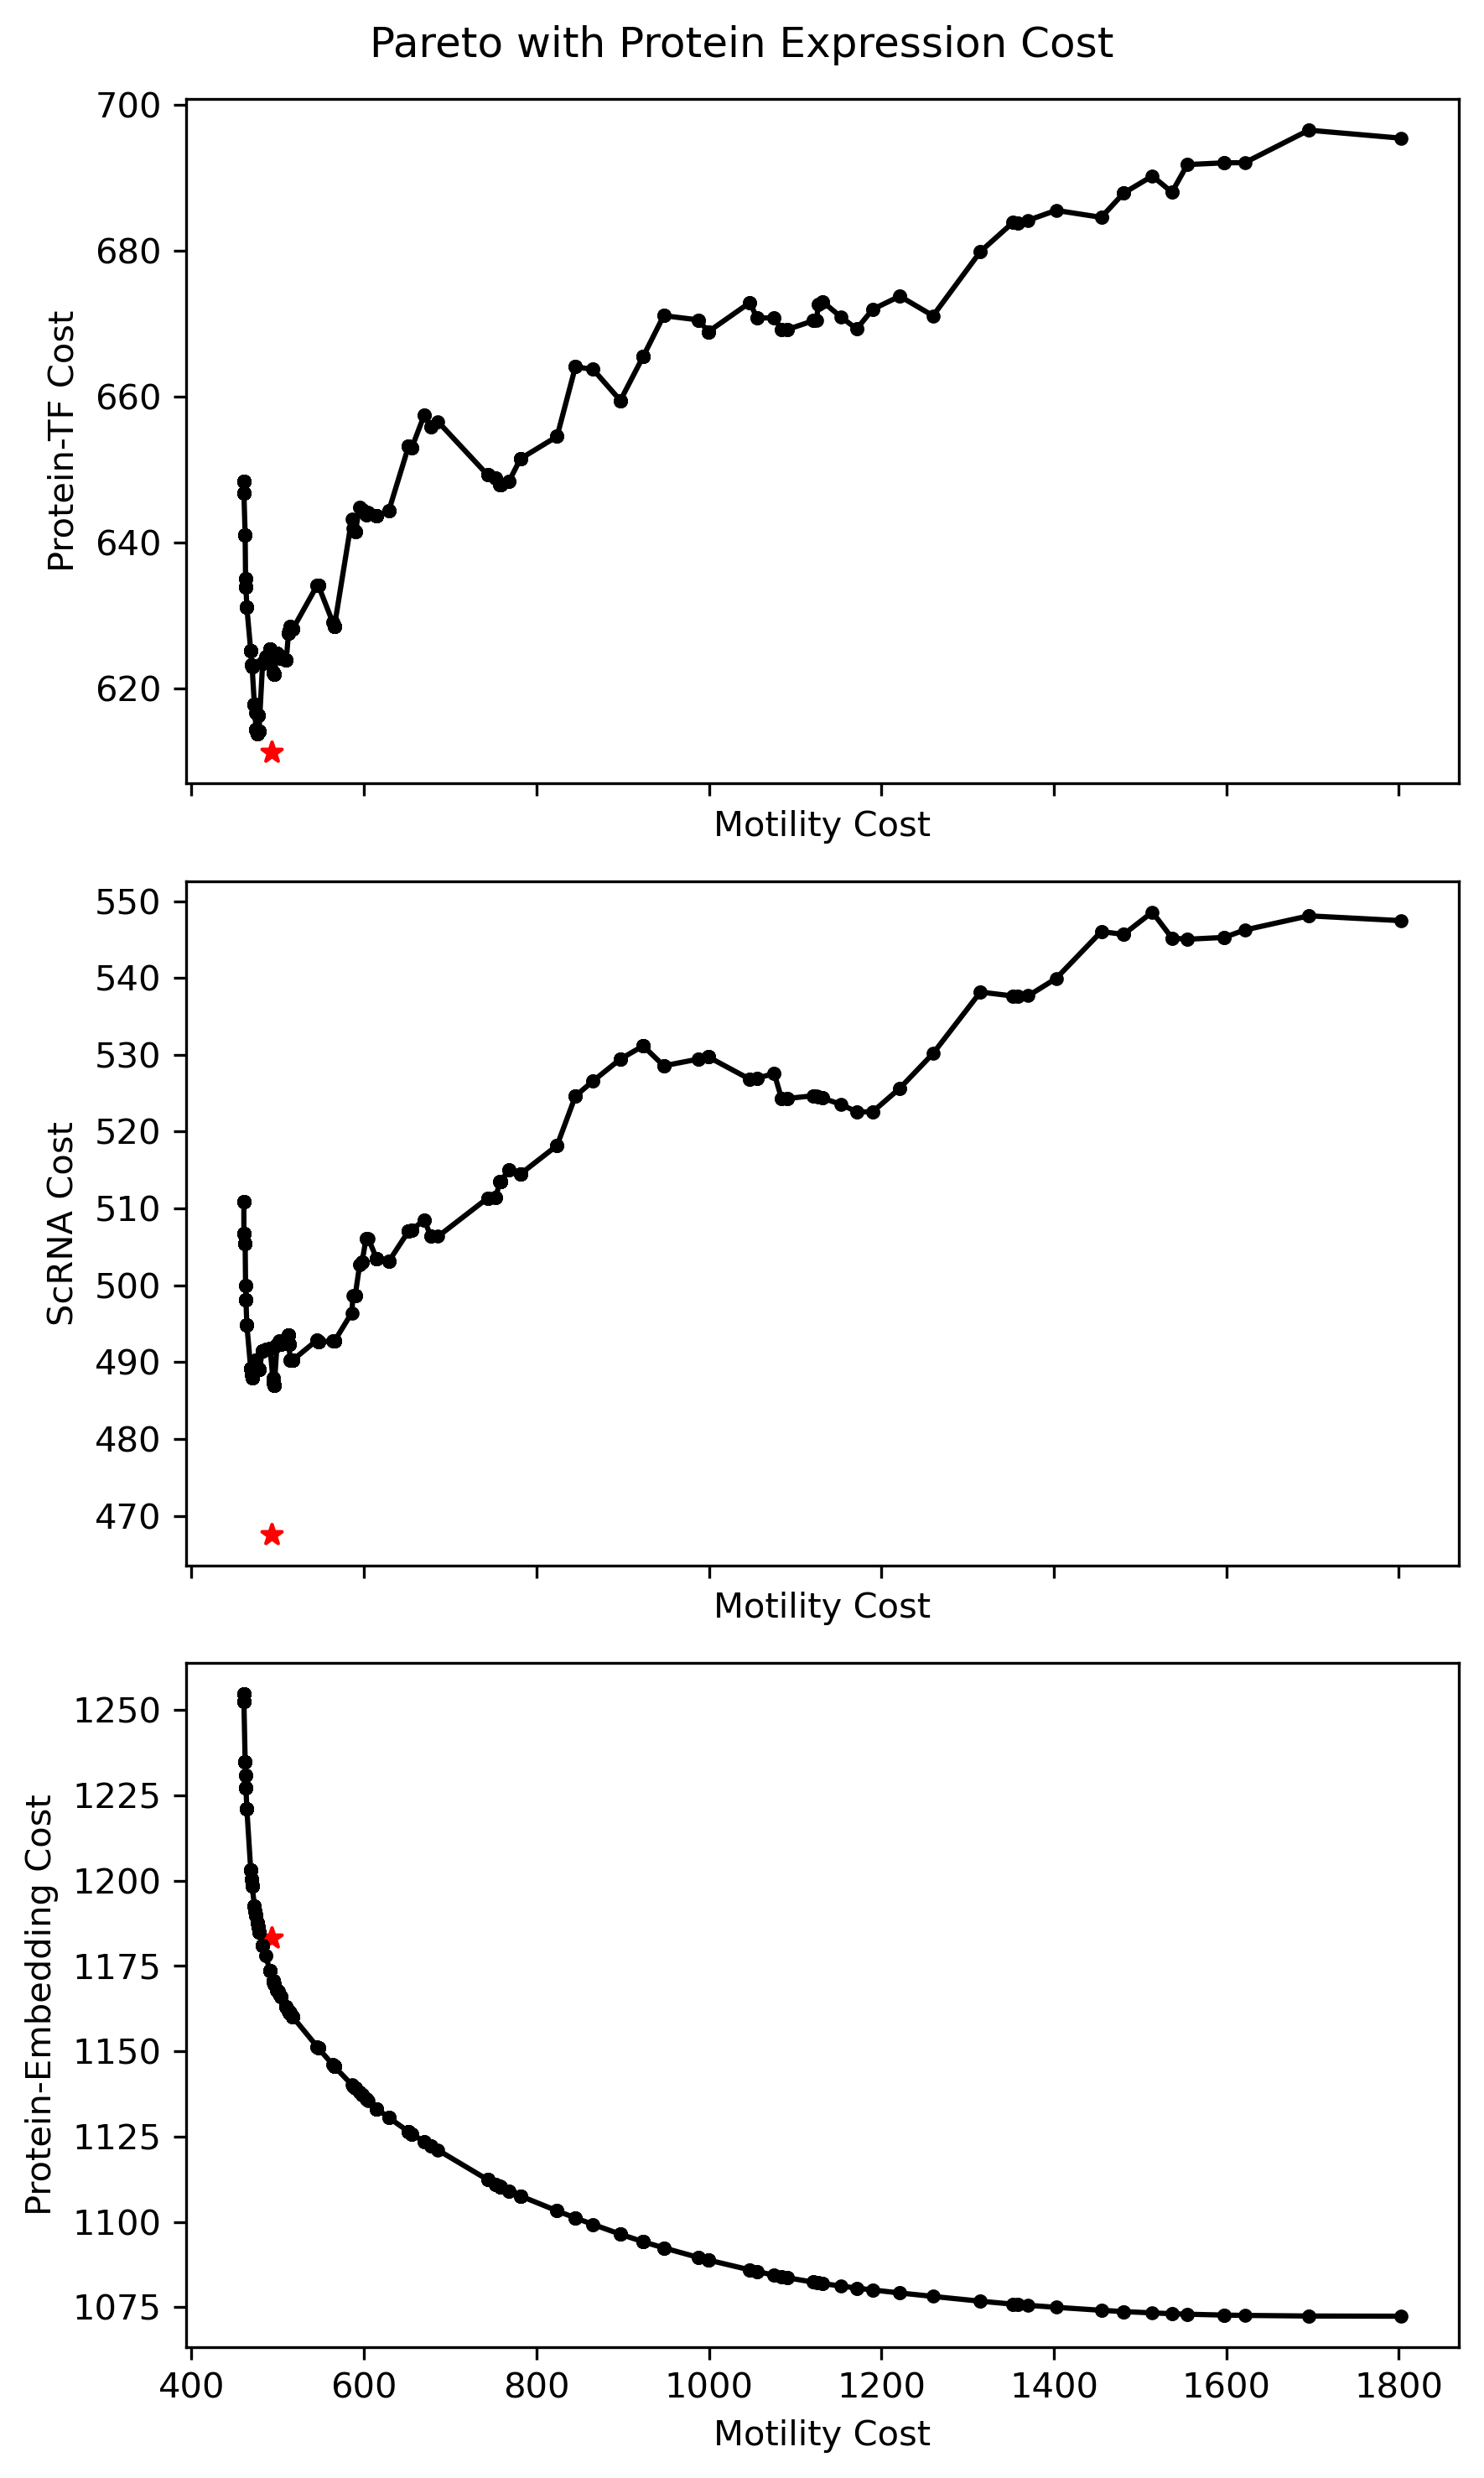

In [71]:
pareto_exp_comp(embedded_exp_cost_mat, "Pareto with Protein Expression Cost")


In [50]:
random_alt_exp_costs = []
for _ in tqdm(range(1000000)):
    col_ind = np.random.permutation(alt_exp_cost_mat.shape[0])
    row_ind = np.arange(alt_exp_cost_mat.shape[0])
    random_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())

100%|██████████| 1000000/1000000 [00:09<00:00, 108801.10it/s]


In [51]:
np.mean(random_alt_exp_costs), np.std(random_alt_exp_costs)

(np.float64(674.7331677597017), np.float64(8.590354441939507))

In [58]:
# get gene_data_df for candidate_tfs
candidate_tf_data_df = gene_data_df.loc[gene_data_df.index.isin(candidate_tfs)]

In [62]:
all_tf_data_df = gene_data_df.loc[gene_data_df.index.isin(name.upper() for name in tf_names)]

In [64]:
candidate_tf_data_df["cel_tau_median_joint"].mean()

np.float64(0.5220147063394972)

In [65]:
all_tf_data_df["cel_tau_median_joint"].mean()

np.float64(0.653863455282491)